In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:


demo = pd.read_csv("segmentation data.csv").drop(columns=["ID"])
num = ["Age","Income"]
cat = ["Sex","Marital status","Education","Occupation","Settlement size"]

prep = ColumnTransformer([
    ("num", StandardScaler(), num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
], remainder="drop")


In [7]:
purchase_data=pd.read_csv("purchase data.csv")




In [8]:
purchase_data["Age"].value_counts()

Age
27    2859
35    2859
31    2759
32    2487
25    2436
26    2403
40    2265
37    2155
36    2011
33    1931
24    1852
34    1811
38    1575
43    1523
30    1513
28    1402
39    1392
45    1339
23    1251
46    1180
49    1091
29    1045
47    1036
51    1032
41    1002
52     986
48     967
44     962
42     958
57     918
65     714
61     683
53     671
63     652
60     585
50     558
55     556
64     546
58     472
54     468
21     467
67     457
56     414
59     402
66     357
22     319
68     269
18     235
20     196
73     121
19     106
71     101
74      94
70      92
62      86
75      72
Name: count, dtype: int64

In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

Xp = prep.fit_transform(demo)
scores = []
for k in [3,4,5,6]:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    lbl = km.fit_predict(Xp)
    scores.append({
        "k": k,
        "sil": silhouette_score(Xp, lbl),
        "ch": calinski_harabasz_score(Xp, lbl),
        "db": davies_bouldin_score(Xp, lbl)
    })
# pick best k by sil↑ & db↓ (and segment interpretability)
best_k = max(scores, key=lambda s: (round(s["sil"],3), -round(s["db"],3)))["k"]
km = KMeans(n_clusters=best_k, n_init=20, random_state=42).fit(Xp)
demo_segments = km.labels_


In [3]:
demo_out = pd.read_csv("segmentation data.csv")
demo_out["Segment"] = demo_segments
segment_profile = demo_out.groupby("Segment")[["Age","Income"]].mean()
cat_profile = (demo_out.groupby("Segment")[["Sex","Marital status","Education","Occupation","Settlement size"]]
               .agg(lambda s: s.value_counts(normalize=True).to_dict()))


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

X_demo = demo
y_demo = demo_segments
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced_subsample")
acc = cross_val_score(rf, X_demo, y_demo, cv=5, scoring="accuracy").mean()
rf.fit(X_demo, y_demo)


,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
purch = pd.read_csv("purchase data.csv")
feature_cols = X_demo.columns  # same demo columns
purch["Segment"] = rf.predict(purch[feature_cols])


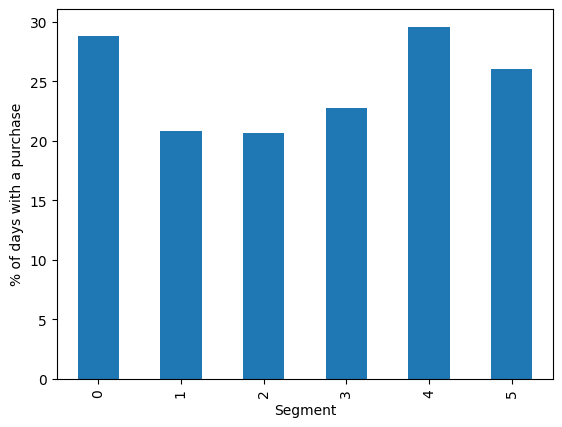

In [6]:
import seaborn as sns, matplotlib.pyplot as plt
ax = (purch.groupby("Segment")["Incidence"].mean()
      .mul(100).rename("Incidence %")).plot(kind="bar")
ax.set_ylabel("% of days with a purchase"); plt.show()


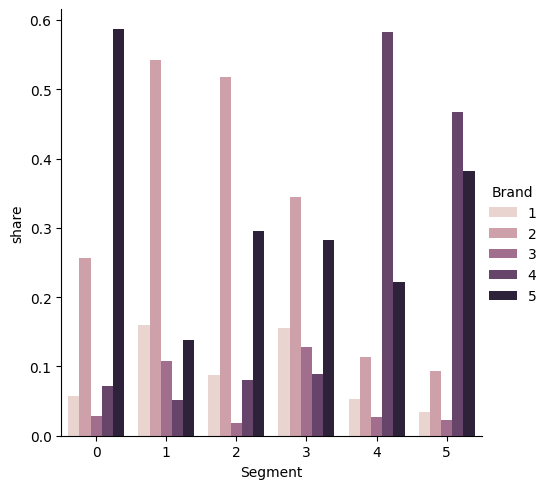

In [10]:
buyers = purch[purch["Incidence"]==1]
share = (buyers.groupby("Segment")["Brand"]
         .value_counts(normalize=True).rename("share").reset_index())
sns.catplot(data=share, x="Segment", y="share", hue="Brand", kind="bar"); plt.show()


In [11]:
pcols = [c for c in purch.columns if c.startswith("Promotion_")]
purch["AnyPromo"] = (purch[pcols].sum(axis=1) > 0).astype(int)
lift = (purch.groupby(["Segment","AnyPromo"])["Incidence"].mean()
        .unstack().assign(lift_pp=lambda d: (d[1]-d[0])*100))
print(lift[["lift_pp"]])


AnyPromo   lift_pp
Segment           
0         4.939903
1         6.674746
2         5.010206
3         5.734992
4         2.332705
5         4.696105


In [12]:
pcols = [c for c in purch.columns if c.startswith("Promotion_")]
purch["AnyPromo"] = (purch[pcols].sum(axis=1) > 0).astype(int)
lift = (purch.groupby(["Segment","AnyPromo"])["Incidence"].mean()
        .unstack().assign(lift_pp=lambda d: (d[1]-d[0])*100))
print(lift[["lift_pp"]])


AnyPromo   lift_pp
Segment           
0         4.939903
1         6.674746
2         5.010206
3         5.734992
4         2.332705
5         4.696105


In [13]:
from sklearn.linear_model import LogisticRegression
import numpy as np

top_by_seg = (buyers.groupby("Segment")["Brand"]
              .value_counts().groupby(level=0).idxmax().apply(lambda x: x[1])).to_dict()

coef = {}
for seg, topb in top_by_seg.items():
    df = purch[purch["Segment"]==seg].copy()
    df["price"] = df[f"Price_{topb}"]
    df["promo"] = df[f"Promotion_{topb}"]
    df["price_z"] = (df["price"]-df["price"].mean())/df["price"].std()
    X = df[["price_z","promo"]]; y = df["Incidence"]
    lr = LogisticRegression(max_iter=1000).fit(X,y)
    coef[seg] = dict(top_brand=int(topb), beta_price=float(lr.coef_[0,0]), beta_promo=float(lr.coef_[0,1]))
coef


{0: {'top_brand': 5,
  'beta_price': -0.019278439469996553,
  'beta_promo': 0.26879884556684996},
 1: {'top_brand': 2,
  'beta_price': -0.1498926331232098,
  'beta_promo': 0.16654796793910764},
 2: {'top_brand': 2,
  'beta_price': -0.19307274241540268,
  'beta_promo': 0.06617727730888066},
 3: {'top_brand': 2,
  'beta_price': -0.10709141206127276,
  'beta_promo': 0.13727065392953922},
 4: {'top_brand': 4,
  'beta_price': -0.04284066162756535,
  'beta_promo': 0.0800131183601613},
 5: {'top_brand': 4,
  'beta_price': -0.07606016553403651,
  'beta_promo': 0.08449250607752769}}